# LSTM: Trajektorie lernen → danach Wurf klassifizieren (clean & noisy)

Zielsetzung:
- Das LSTM lernt die Trajektorie \((x(t), y(t))\) aus Eingaben `[theta, v0, hs, t]`.
- Nach dem Training wird jede vorhergesagte Trajektorie je `wurf_id` deterministisch klassifiziert:
  `0=zu kurz`, `1=Treffer`, `2=zu lang`.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Datensatz vs. Vorhersage), wurfweise Konfusionsmatrix & Metriken, Vergleichstabelle.

Klassifikations-Heuristik:
Am Korb-Plane `x = l`: Falls `max(x_pred) < l` ⇒ zu kurz. Sonst `y_pred` an `x=l` linear interpolieren.
Wenn `hKorb - (Rr - Rb) ≤ y_pred(l) ≤ hKorb + (Rr - Rb)` ⇒ Treffer, sonst zu lang.

In [1]:
import os, sys, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print('Python', sys.version)
print('Torch', torch.__version__)


Python 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Torch 2.6.0+cpu


In [2]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25*hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g/(2*(l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx=v0*np.cos(theta); vy=v0*np.sin(theta)
        x = vx*t; y = vy*t - 0.5*g*t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise: df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2*v0*np.sin(theta)/g; t = np.linspace(0, T, 50)
            x,y = self.wurftrajektorien(theta, v0, t)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x,y,t):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


In [3]:
def df_to_pointwise_tensors(df, hs_val=2.13, device='cpu'):
    d = df.copy()
    if 't' not in d.columns:
        d['vx'] = d['v0']*np.cos(d['theta'])
        d['vx'] = d['vx'].replace(0, 1e-8)
        d['t'] = d['x']/d['vx']
    d['t'] = d['t'].clip(lower=0.0)
    d['hs'] = hs_val
    d = d.dropna(subset=['theta','v0','t','x','y','label','wurf_id'])
    X = d[['theta','v0','hs','t']].values.astype(np.float32)
    Y = d[['x','y']].values.astype(np.float32)
    X_seq = X.reshape(-1,1,4)
    Xt = torch.tensor(X_seq, dtype=torch.float32, device=device)
    Yt = torch.tensor(Y, dtype=torch.float32, device=device)
    return Xt, Yt, d


In [4]:
class LSTMxy(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.head(out)


In [5]:
def train_epoch(model, loader, optim, crit, device):
    model.train(); tloss=0; N=0
    for X,Y in loader:
        X,Y = X.to(device), Y.to(device)
        optim.zero_grad(); pred = model(X)
        loss = crit(pred, Y)
        loss.backward(); optim.step()
        bs = X.size(0); tloss += loss.item()*bs; N+=bs
    return tloss/max(N,1)

def eval_epoch(model, loader, crit, device):
    model.eval(); tloss=0; N=0; preds=[]; gts=[]
    with torch.no_grad():
        for X,Y in loader:
            X,Y = X.to(device), Y.to(device)
            pred = model(X)
            loss = crit(pred, Y)
            bs = X.size(0); tloss += loss.item()*bs; N+=bs
            preds.append(pred.cpu().numpy()); gts.append(Y.cpu().numpy())
    return tloss/max(N,1), (np.vstack(preds), np.vstack(gts))


In [6]:
def classify_wurf_from_prediction(df_wurf, l, hKorb, Rr, Rb, eps=1e-3):
    g = df_wurf.sort_values('x_pred')
    if g['x_pred'].max() < l - eps:
        return 0
    before = g[g['x_pred'] <= l]
    after  = g[g['x_pred'] >= l]
    if before.empty or after.empty:
        idx = (g['x_pred']-l).abs().idxmin()
        y_at_l = g.loc[idx, 'y_pred']
    else:
        i1 = before.index[-1]; i2 = after.index[0]
        x1,y1 = g.loc[i1,'x_pred'], g.loc[i1,'y_pred']
        x2,y2 = g.loc[i2,'x_pred'], g.loc[i2,'y_pred']
        if abs(x2-x1) < 1e-8:
            y_at_l = y1
        else:
            w = (l - x1) / (x2 - x1)
            y_at_l = y1 + w*(y2 - y1)
    win_lo = hKorb - (Rr - Rb)
    win_hi = hKorb + (Rr - Rb)
    return 1 if (win_lo <= y_at_l <= win_hi) else 2

def evaluate_throw_level(pred_df, params):
    l, hK, Rr, Rb = params['l'], params['hKorb'], params['Rr'], params['Rb']
    true_labels = pred_df.groupby('wurf_id')['label'].first()
    pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))
    y_true = true_labels.values; y_pred = pred_labels.values
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'cm':cm, 'acc':acc, 'prec':prec, 'rec':rec, 'f1':f1, 'y_true':y_true, 'y_pred':y_pred}


## Clean‑Training → Wurfklassifikation

Epoch 01 | train_loss=8.149487 | val_loss=6.037190
Epoch 02 | train_loss=4.040441 | val_loss=2.070764
Epoch 03 | train_loss=1.327523 | val_loss=0.955345
Epoch 05 | train_loss=0.878347 | val_loss=0.870019
Epoch 10 | train_loss=0.602491 | val_loss=0.550730
Epoch 15 | train_loss=0.150668 | val_loss=0.131564
Epoch 20 | train_loss=0.090671 | val_loss=0.091044
Epoch 25 | train_loss=0.082773 | val_loss=0.083325
Epoch 30 | train_loss=0.075905 | val_loss=0.076634
Epoch 35 | train_loss=0.068833 | val_loss=0.069182
Epoch 40 | train_loss=0.061096 | val_loss=0.061269
Epoch 45 | train_loss=0.052458 | val_loss=0.052425
Epoch 50 | train_loss=0.042933 | val_loss=0.042715
Epoch 55 | train_loss=0.032669 | val_loss=0.032199
Epoch 60 | train_loss=0.022427 | val_loss=0.021973
Epoch 65 | train_loss=0.013917 | val_loss=0.013523
Epoch 70 | train_loss=0.008180 | val_loss=0.008045
Epoch 75 | train_loss=0.005286 | val_loss=0.005292
Epoch 80 | train_loss=0.003981 | val_loss=0.004001
Epoch 85 | train_loss=0.003417 

C:\Users\luca1\AppData\Local\Temp\ipykernel_21448\3191284282.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))


Clean throw-level metrics:
Accuracy= 0.88  Precision= 0.9117647058823529  Recall= 0.88  F1= 0.8827365022726307


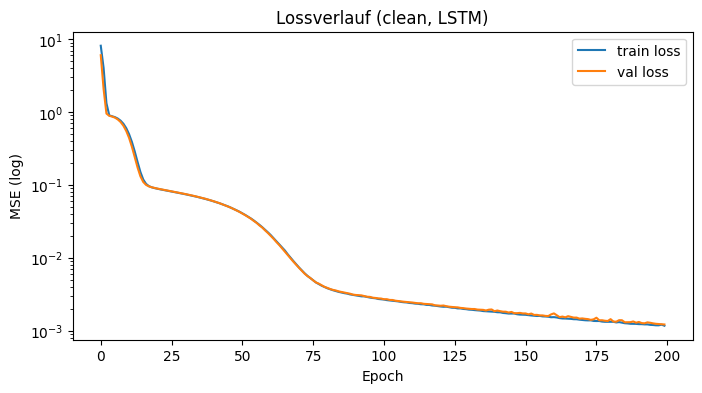

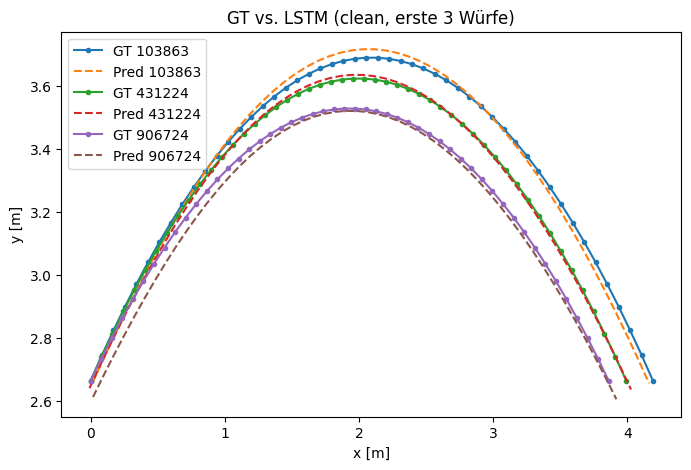

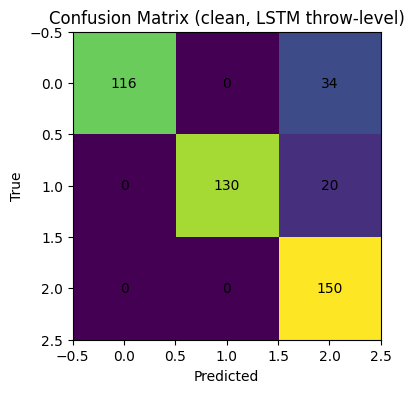

In [ ]:
device='cpu'
sim = DataGen(hs=2.13)
params = sim.params if hasattr(sim,'params') else {'l':4.115,'hKorb':3.048,'Rr':0.2286,'Rb':0.1219}
df_clean = sim.generate_dataset(n=150, with_noise=False)
Xt, Yt, dproc = df_to_pointwise_tensors(df_clean, hs_val=2.13, device='cpu')
n = len(Xt); idx = np.random.permutation(n)
tr = int(0.8*n); va = int(0.9*n)
train_loader = DataLoader(torch.utils.data.TensorDataset(Xt[idx[:tr]], Yt[idx[:tr]]), batch_size=512, shuffle=True)
val_loader   = DataLoader(torch.utils.data.TensorDataset(Xt[idx[tr:va]], Yt[idx[tr:va]]), batch_size=512, shuffle=False)
test_loader  = DataLoader(torch.utils.data.TensorDataset(Xt[idx[va:]], Yt[idx[va:]]), batch_size=512, shuffle=False)

model = LSTMxy(input_size=4, hidden_size=64, num_layers=1).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
crit = nn.MSELoss()
hist={'train_loss':[], 'val_loss':[]}
for ep in range(200):
    tr_loss = train_epoch(model, train_loader, opt, crit, device)
    va_loss, _ = eval_epoch(model, val_loader, crit, device)
    hist['train_loss'].append(tr_loss); hist['val_loss'].append(va_loss)
    if (ep+1)%5==0 or ep<3:
        print(f'Epoch {ep+1:02d} | train_loss={tr_loss:.6f} | val_loss={va_loss:.6f}')

plt.figure(figsize=(8,4))
plt.plot(hist['train_loss'], label='train loss')
plt.plot(hist['val_loss'], label='val loss')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('MSE (log)'); plt.legend(); plt.title('Lossverlauf (clean, LSTM)')

model.eval()
with torch.no_grad():
    pred_xy = model(Xt).cpu().numpy()
dproc_pred = dproc.copy(); dproc_pred['x_pred']=pred_xy[:,0]; dproc_pred['y_pred']=pred_xy[:,1]

ids = dproc_pred['wurf_id'].unique()[:3]
plt.figure(figsize=(8,5))
for wid in ids:
    g_gt = dproc[dproc['wurf_id']==wid].sort_values('t')
    g_pr = dproc_pred[dproc_pred['wurf_id']==wid].sort_values('t')
    plt.plot(g_gt['x'], g_gt['y'], marker='.', label=f'GT {wid[:6]}')
    plt.plot(g_pr['x_pred'], g_pr['y_pred'], linestyle='--', label=f'Pred {wid[:6]}')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('GT vs. LSTM (clean, erste 3 Würfe)'); plt.legend()

eval_clean = evaluate_throw_level(dproc_pred, params)
print('Clean throw-level metrics:')
print('Accuracy=', eval_clean['acc'], ' Precision=', eval_clean['prec'], ' Recall=', eval_clean['rec'], ' F1=', eval_clean['f1'])
cm = eval_clean['cm']
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion Matrix (clean, LSTM throw-level)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')


## Noisy‑Training → Wurfklassifikation

[noisy] Epoch 01 | train_loss=7.658280 | val_loss=5.735321
[noisy] Epoch 02 | train_loss=3.757321 | val_loss=1.978787
[noisy] Epoch 03 | train_loss=1.275992 | val_loss=0.902092
[noisy] Epoch 05 | train_loss=0.876561 | val_loss=0.829588
[noisy] Epoch 10 | train_loss=0.610766 | val_loss=0.551358
[noisy] Epoch 15 | train_loss=0.179769 | val_loss=0.148150
[noisy] Epoch 20 | train_loss=0.101760 | val_loss=0.100177
[noisy] Epoch 25 | train_loss=0.093710 | val_loss=0.092485
[noisy] Epoch 30 | train_loss=0.086522 | val_loss=0.084754
[noisy] Epoch 35 | train_loss=0.077495 | val_loss=0.075458
[noisy] Epoch 40 | train_loss=0.067368 | val_loss=0.065341
[noisy] Epoch 45 | train_loss=0.056865 | val_loss=0.054736
[noisy] Epoch 50 | train_loss=0.045306 | val_loss=0.043408
[noisy] Epoch 55 | train_loss=0.033473 | val_loss=0.032076
[noisy] Epoch 60 | train_loss=0.023613 | val_loss=0.022797
[noisy] Epoch 65 | train_loss=0.017493 | val_loss=0.017143
[noisy] Epoch 70 | train_loss=0.014703 | val_loss=0.0148

C:\Users\luca1\AppData\Local\Temp\ipykernel_21448\3191284282.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))


Noisy throw-level metrics:
Accuracy= 0.9088888888888889  Precision= 0.9284467713787086  Recall= 0.9088888888888889  F1= 0.9090939203103363
Vergleich (wurf-level):
     set       acc      prec       rec        f1
0  clean  0.880000  0.911765  0.880000  0.882737
1  noisy  0.908889  0.928447  0.908889  0.909094


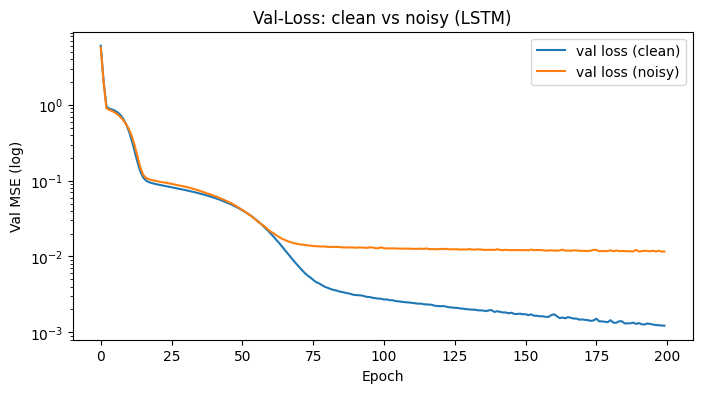

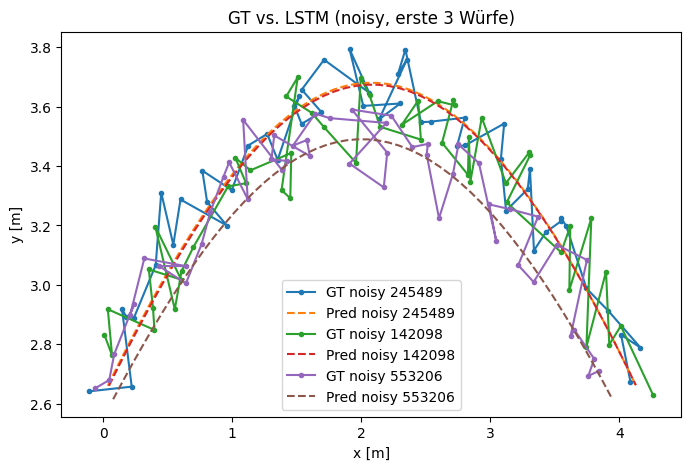

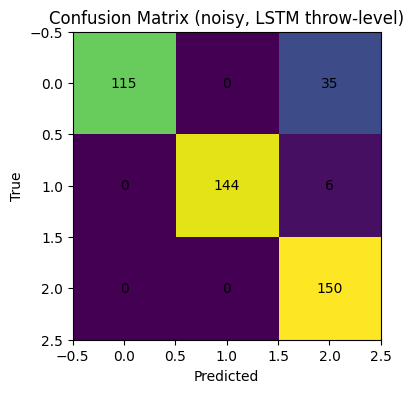

In [8]:
df_noisy = sim.generate_dataset(n=150, with_noise=True)
Xtn, Ytn, dproc_n = df_to_pointwise_tensors(df_noisy, hs_val=2.13, device='cpu')
n2 = len(Xtn); idx2 = np.random.permutation(n2)
tr2 = int(0.8*n2); va2 = int(0.9*n2)
train_loader_n = DataLoader(torch.utils.data.TensorDataset(Xtn[idx2[:tr2]], Ytn[idx2[:tr2]]), batch_size=512, shuffle=True)
val_loader_n   = DataLoader(torch.utils.data.TensorDataset(Xtn[idx2[tr2:va2]], Ytn[idx2[tr2:va2]]), batch_size=512, shuffle=False)
test_loader_n  = DataLoader(torch.utils.data.TensorDataset(Xtn[idx2[va2:]], Ytn[idx2[va2:]]), batch_size=512, shuffle=False)

model_n = LSTMxy(input_size=4, hidden_size=64, num_layers=1).to(device)
opt_n = optim.Adam(model_n.parameters(), lr=1e-3)
crit_n = nn.MSELoss()
hist_n={'train_loss':[], 'val_loss':[]}
for ep in range(200):
    tr_loss = train_epoch(model_n, train_loader_n, opt_n, crit_n, device)
    va_loss, _ = eval_epoch(model_n, val_loader_n, crit_n, device)
    hist_n['train_loss'].append(tr_loss); hist_n['val_loss'].append(va_loss)
    if (ep+1)%5==0 or ep<3:
        print(f'[noisy] Epoch {ep+1:02d} | train_loss={tr_loss:.6f} | val_loss={va_loss:.6f}')

plt.figure(figsize=(8,4))
plt.plot(hist['val_loss'], label='val loss (clean)')
plt.plot(hist_n['val_loss'], label='val loss (noisy)')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Val MSE (log)'); plt.legend(); plt.title('Val-Loss: clean vs noisy (LSTM)')

model_n.eval()
with torch.no_grad():
    pred_xy_n = model_n(Xtn).cpu().numpy()
dproc_pred_n = dproc_n.copy(); dproc_pred_n['x_pred']=pred_xy_n[:,0]; dproc_pred_n['y_pred']=pred_xy_n[:,1]

ids2 = dproc_pred_n['wurf_id'].unique()[:3]
plt.figure(figsize=(8,5))
for wid in ids2:
    g_gt = dproc_n[dproc_n['wurf_id']==wid].sort_values('t')
    g_pr = dproc_pred_n[dproc_pred_n['wurf_id']==wid].sort_values('t')
    plt.plot(g_gt['x'], g_gt['y'], marker='.', label=f'GT noisy {wid[:6]}')
    plt.plot(g_pr['x_pred'], g_pr['y_pred'], linestyle='--', label=f'Pred noisy {wid[:6]}')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('GT vs. LSTM (noisy, erste 3 Würfe)'); plt.legend()

eval_noisy = evaluate_throw_level(dproc_pred_n, params)
print('Noisy throw-level metrics:')
print('Accuracy=', eval_noisy['acc'], ' Precision=', eval_noisy['prec'], ' Recall=', eval_noisy['rec'], ' F1=', eval_noisy['f1'])
cmn = eval_noisy['cm']
plt.figure(figsize=(5,4))
plt.imshow(cmn)
plt.title('Confusion Matrix (noisy, LSTM throw-level)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, cmn[i,j], ha='center', va='center')

comp = pd.DataFrame([
    {'set':'clean','acc':eval_clean['acc'],'prec':eval_clean['prec'],'rec':eval_clean['rec'],'f1':eval_clean['f1']},
    {'set':'noisy','acc':eval_noisy['acc'],'prec':eval_noisy['prec'],'rec':eval_noisy['rec'],'f1':eval_noisy['f1']},
])
print('Vergleich (wurf-level):')
print(comp)
